In [1]:
import kagglehub

path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print("Path:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path: /kaggle/input/gtzan-dataset-music-genre-classification


In [2]:
dataset_path = f"{path}/Data/images_original"

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total images: 999


In [7]:
from sklearn.model_selection import train_test_split
import torch

targets = [label for _, label in dataset]

train_idx, test_idx = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset  = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(dataset.classes)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [ ]:
for epoch in range(100):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 72.6453
Epoch 2, Loss: 51.0810
Epoch 3, Loss: 48.7880
Epoch 4, Loss: 48.3077
Epoch 5, Loss: 46.6927
Epoch 6, Loss: 44.5811
Epoch 7, Loss: 44.8772
Epoch 8, Loss: 43.0332
Epoch 9, Loss: 43.1870
Epoch 10, Loss: 42.2012
Epoch 11, Loss: 40.3469
Epoch 12, Loss: 39.8065
Epoch 13, Loss: 38.5297
Epoch 14, Loss: 38.3539
Epoch 15, Loss: 36.2620
Epoch 16, Loss: 36.6885
Epoch 17, Loss: 36.3397
Epoch 18, Loss: 35.7734
Epoch 19, Loss: 36.0550
Epoch 20, Loss: 35.5326
Epoch 21, Loss: 34.9410
Epoch 22, Loss: 33.5653
Epoch 23, Loss: 33.3179
Epoch 24, Loss: 33.7893
Epoch 25, Loss: 33.0616
Epoch 26, Loss: 33.7693
Epoch 27, Loss: 32.8866
Epoch 28, Loss: 32.4964
Epoch 29, Loss: 32.1432
Epoch 30, Loss: 32.4070
Epoch 31, Loss: 32.1925
Epoch 32, Loss: 31.4070
Epoch 33, Loss: 31.5268
Epoch 34, Loss: 30.6213
Epoch 35, Loss: 31.3543
Epoch 36, Loss: 31.6653
Epoch 37, Loss: 30.6634
Epoch 38, Loss: 30.3546
Epoch 39, Loss: 30.7999
Epoch 40, Loss: 29.8905
Epoch 41, Loss: 29.0448
Epoch 42, Loss: 29.2462
E

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

Accuracy: 0.665
F1 Score: 0.6606884680636754


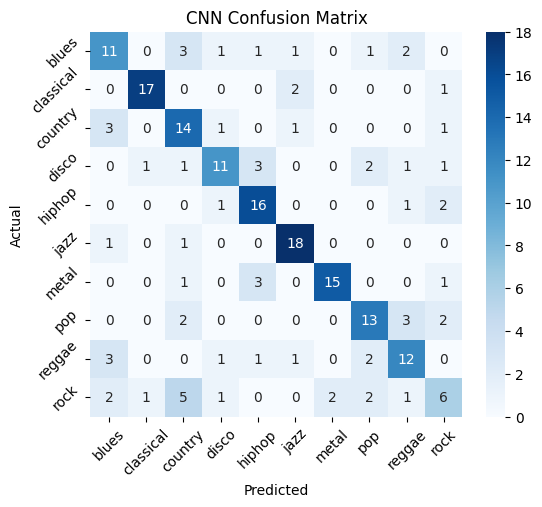

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

#Pre-Trained Models:

In [8]:
from sklearn.model_selection import train_test_split

targets = [label for _, label in dataset]

train_idx, test_idx = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset  = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [9]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))

# Unfreeze ALL layers (full fine-tuning)
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

# Optimizer (only trainable params)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5,           # VERY IMPORTANT
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


In [10]:
for epoch in range(100):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # optional

        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 57.7886
Epoch 2, Loss: 43.7780
Epoch 3, Loss: 35.2571
Epoch 4, Loss: 30.4457
Epoch 5, Loss: 26.3645
Epoch 6, Loss: 24.0052
Epoch 7, Loss: 21.7639
Epoch 8, Loss: 19.8643
Epoch 9, Loss: 18.3784
Epoch 10, Loss: 16.7004
Epoch 11, Loss: 15.8616
Epoch 12, Loss: 14.4903
Epoch 13, Loss: 13.0053
Epoch 14, Loss: 12.6644
Epoch 15, Loss: 11.3660
Epoch 16, Loss: 9.9219
Epoch 17, Loss: 10.2371
Epoch 18, Loss: 9.2760
Epoch 19, Loss: 8.1941
Epoch 20, Loss: 7.4910
Epoch 21, Loss: 7.2148
Epoch 22, Loss: 6.1356
Epoch 23, Loss: 5.5312
Epoch 24, Loss: 5.1146
Epoch 25, Loss: 4.3381
Epoch 26, Loss: 4.3591
Epoch 27, Loss: 3.5879
Epoch 28, Loss: 3.3710
Epoch 29, Loss: 3.1803
Epoch 30, Loss: 2.8946
Epoch 31, Loss: 2.3158
Epoch 32, Loss: 2.3246
Epoch 33, Loss: 2.2981
Epoch 34, Loss: 2.5278
Epoch 35, Loss: 1.8926
Epoch 36, Loss: 1.9919
Epoch 37, Loss: 1.4384
Epoch 38, Loss: 1.3082
Epoch 39, Loss: 1.4077
Epoch 40, Loss: 1.6493
Epoch 41, Loss: 1.0353
Epoch 42, Loss: 1.1118
Epoch 43, Loss: 0.9059
Epoc

In [11]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

Accuracy: 0.795
F1 Score: 0.7968924735227687


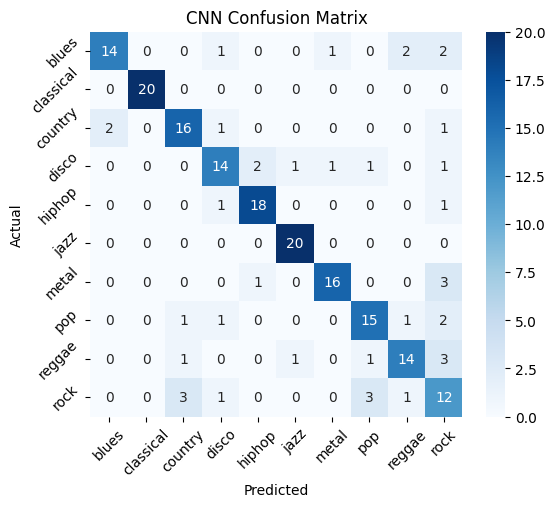

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()